**Instructions**:
1. Place your dataset folder next to this notebook (see Step 3)
2. Run all cells in order (`Cell → Run All`)
3. Outputs (model weights, plots, zip) are saved in the notebook directory


## Step 1 — Install Dependencies

In [1]:
# Install all required libraries
!pip install -q "transformers>=4.41.0" albumentations==1.4.3 segmentation-models-pytorch timm
# Standard PyTorch build already includes MPS (Apple Metal) support — no extra flags needed
!pip install -q torch torchvision

print('✅ All dependencies installed!')


✅ All dependencies installed!


## Step 2 — Check GPU

In [2]:
import torch

# Apple Silicon GPU (M1/M2/M3/M4) via Metal Performance Shaders
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Execution Device : Apple GPU (MPS / Metal)')
    print('MPS built        :', torch.backends.mps.is_built())
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Execution Device : CUDA — {torch.cuda.get_device_name(0)}')
    print(f'VRAM             : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    device = torch.device('cpu')
    print('Execution Device : CPU  (MPS not available — training will be slow)')

print(f'torch version    : {torch.__version__}')
print(f'device           : {device}')


Execution Device : Apple GPU (MPS / Metal)
MPS built        : True
torch version    : 2.11.0
device           : mps


## Step 3 — Mount Google Drive & Set Dataset Paths

**Before running this step:**
1. Upload your dataset to Google Drive (if not already there)
2. Set `GDRIVE_DATASET_PATH` below to the folder containing your data
   - e.g. `'./dataset12kpatches'`
3. Your folder should contain two subfolders: images and masks


In [3]:
# ── Step 3: Set Dataset Path ─────────────────────────────
# Place your downloaded dataset folder next to this notebook,
# or change DATASET_PATH to an absolute path on your machine.
#
# Expected structure:
#   dataset12kpatches/
#       out_original_aug/     ← input images
#       out_groundtruth_aug/  ← binary masks
#
# Download from Kaggle:
#   kaggle datasets download -d srsnit/dataset12kpatches
#   unzip dataset12kpatches.zip

import os
DATASET_PATH = './dataset12kpatches'  # <-- change this if needed
print(f'Dataset path set to: {os.path.abspath(DATASET_PATH)}')
print('✅ Ready!')


Dataset path set to: /Users/deepakkambala/Jupyter/dataset12kpatches
✅ Ready!


In [4]:
import os, shutil

# ============================================================
# SET YOUR LOCAL DATASET PATH HERE
# ============================================================
DATASET_PATH = './dataset_12K'  # <-- change this
# ============================================================

LOCAL_DATA = './data'

if os.path.exists(LOCAL_DATA):
    print(f'ℹ️  {LOCAL_DATA} already exists — skipping copy.')
else:
    print(f'📂 Copying dataset to {LOCAL_DATA} ...')
    shutil.copytree(DATASET_PATH, LOCAL_DATA)
    print(f'✅ Dataset copied to {LOCAL_DATA}')

# List top-level structure
print('\nDataset structure:')
for root, dirs, files in os.walk(LOCAL_DATA):
    level = root.replace(LOCAL_DATA, '').count(os.sep)
    if level > 1:
        break
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = '  ' * (level + 1)
    for f in files[:3]:
        print(f'{subindent}{f}')
    if len(files) > 3:
        print(f'{subindent}... ({len(files)} total files)')


ℹ️  ./data already exists — skipping copy.

Dataset structure:
data/
  .DS_Store
  out_groundtruth_aug/
    10_orig_00037.png
    24_orig_00211.png
    03_orig_00193.png
    ... (12000 total files)
  out_original_aug/
    10_orig_00037.png
    24_orig_00211.png
    03_orig_00193.png
    ... (12000 total files)


## Step 4 — Auto-detect Dataset Paths & Split Data

In [5]:
import os, glob
from pathlib import Path

# Auto-find the two folders regardless of exact extraction structure
def find_folder(root, keywords):
    for kw in keywords:
        matches = glob.glob(f'{root}/**/*{kw}*', recursive=True)
        for m in matches:
            if os.path.isdir(m):
                return m
    return None

DATA_ROOT = './data'

IMG_DIR  = find_folder(DATA_ROOT, ['original', 'orig'])
MASK_DIR = find_folder(DATA_ROOT, ['groundtruth', 'ground_truth', 'gt', 'mask'])

# Fallback: let user set manually if auto-detect fails
if IMG_DIR is None or MASK_DIR is None:
    all_dirs = [d for d in glob.glob(f'{DATA_ROOT}/**/', recursive=True)]
    print('Could not auto-detect. Available folders:')
    for d in all_dirs:
        print(' ', d)
    print('\nSet IMG_DIR and MASK_DIR manually below.')
    # MANUAL OVERRIDE (uncomment and fill if auto-detect fails)
    # IMG_DIR  = './data/out_original_aug'
    # MASK_DIR = './data/out_groundtruth_aug'
else:
    print(f'✅ Images : {IMG_DIR}')
    print(f'✅ Masks  : {MASK_DIR}')
    img_count  = len([f for f in os.listdir(IMG_DIR) if f.endswith(('.png','.jpg','.jpeg'))])
    mask_count = len([f for f in os.listdir(MASK_DIR) if f.endswith(('.png','.jpg','.jpeg'))])
    print(f'\n   Image count : {img_count}')
    print(f'   Mask count  : {mask_count}')

✅ Images : ./data/out_original_aug
✅ Masks  : ./data/out_groundtruth_aug

   Image count : 12000
   Mask count  : 12000


In [6]:
import random
import numpy as np

# Reproducible seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Get all image filenames (paired by name with masks)
all_imgs = sorted([
    f for f in os.listdir(IMG_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])

# Verify pairing — every image must have a corresponding mask
mask_files = set(os.listdir(MASK_DIR))
valid_imgs = [f for f in all_imgs if f in mask_files]
missing    = len(all_imgs) - len(valid_imgs)
print(f'Total images     : {len(all_imgs)}')
print(f'Valid pairs      : {len(valid_imgs)}')
if missing > 0:
    print(f'⚠️  Missing masks  : {missing} (will be skipped)')

# Shuffle and split 70/15/15
random.shuffle(valid_imgs)
n = len(valid_imgs)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_files = valid_imgs[:n_train]
val_files   = valid_imgs[n_train:n_train + n_val]
test_files  = valid_imgs[n_train + n_val:]

print(f'\nSplit (70/15/15):')
print(f'  Train : {len(train_files)}')
print(f'  Val   : {len(val_files)}')
print(f'  Test  : {len(test_files)}')

Total images     : 12000
Valid pairs      : 12000

Split (70/15/15):
  Train : 8400
  Val   : 1800
  Test  : 1800


## Step 5 — Visualise Sample Images & Masks

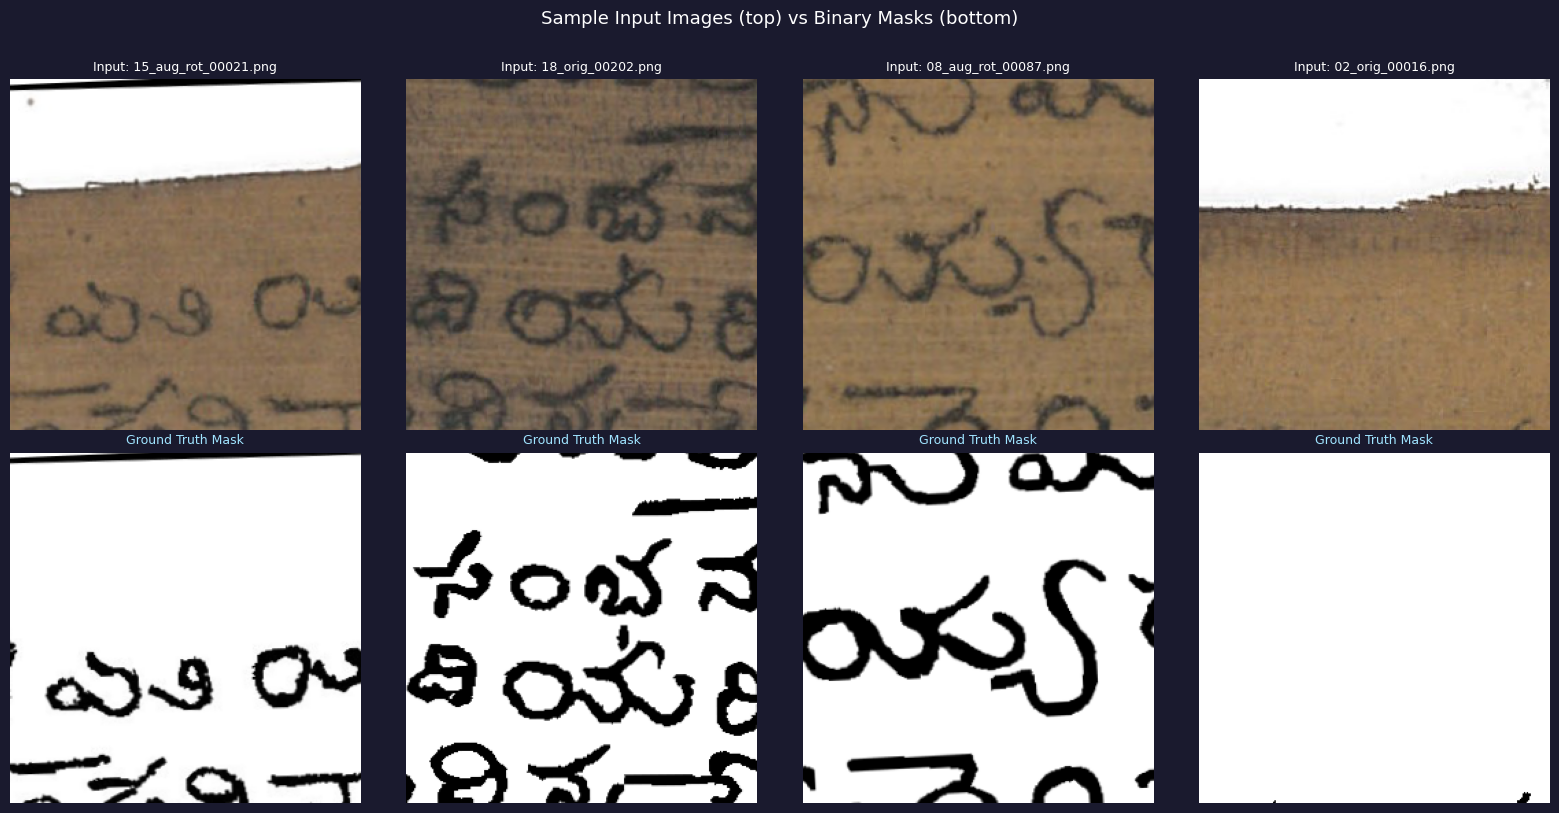

✅ Saved: ./sample_pairs.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

fig = plt.figure(figsize=(16, 8))
fig.patch.set_facecolor('#1a1a2e')
samples = random.sample(train_files, min(4, len(train_files)))

for i, fname in enumerate(samples):
    img  = Image.open(os.path.join(IMG_DIR,  fname)).convert('RGB')
    mask = Image.open(os.path.join(MASK_DIR, fname)).convert('L')

    ax1 = fig.add_subplot(2, 4, i + 1)
    ax1.imshow(img)
    ax1.set_title(f'Input: {fname[:20]}', color='white', fontsize=9)
    ax1.axis('off')

    ax2 = fig.add_subplot(2, 4, i + 5)
    ax2.imshow(mask, cmap='gray')
    ax2.set_title('Ground Truth Mask', color='#a0e4ff', fontsize=9)
    ax2.axis('off')

plt.suptitle('Sample Input Images (top) vs Binary Masks (bottom)', 
             color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('./sample_pairs.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print('✅ Saved: ./sample_pairs.png')

## Step 6 — Dataset Class + Augmentations

In [8]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image

IMG_SIZE   = 128   # 256 works well on Mac; raise to 512 if you have enough RAM
BATCH_SIZE = 2     # 4 is safe on Apple Silicon; raise to 8 if no OOM

# ── Augmentation pipelines ──────────────────────────────────
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.OneOf([
        A.GaussNoise(var_limit=(10, 50)),
        A.ISONoise(),
        A.MultiplicativeNoise(),
    ], p=0.3),
    A.OneOf([
        A.ColorJitter(brightness=0.2, contrast=0.3, saturation=0.2),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.25),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20),
    ], p=0.4),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 7)),
        A.MotionBlur(blur_limit=7),
    ], p=0.2),
    A.ElasticTransform(alpha=1, sigma=50, p=0.15),
    A.GridDistortion(p=0.1),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# ── Dataset class ───────────────────────────────────────────
class TextSegDataset(Dataset):
    def __init__(self, file_list, img_dir, mask_dir, transform=None):
        self.files     = file_list
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img   = np.array(Image.open(os.path.join(self.img_dir,  fname)).convert('RGB'))
        mask  = np.array(Image.open(os.path.join(self.mask_dir, fname)).convert('L'))
        mask  = (mask > 127).astype(np.uint8)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask']

        return img, mask.long()

# ── DataLoaders ─────────────────────────────────────────────
# num_workers=0  : macOS/Jupyter can't pickle notebook-defined classes in workers
# pin_memory=False: not supported on MPS
train_ds = TextSegDataset(train_files, IMG_DIR, MASK_DIR, train_transform)
val_ds   = TextSegDataset(val_files,   IMG_DIR, MASK_DIR, val_transform)
test_ds  = TextSegDataset(test_files,  IMG_DIR, MASK_DIR, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f'✅ Datasets ready!')
print(f'   IMG_SIZE      : {IMG_SIZE}')
print(f'   BATCH_SIZE    : {BATCH_SIZE}')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')
print(f'   Test batches  : {len(test_loader)}')

imgs, masks = next(iter(train_loader))
print(f'\nBatch shapes:')
print(f'   Images : {imgs.shape}   dtype={imgs.dtype}')
print(f'   Masks  : {masks.shape}  dtype={masks.dtype}')
print(f'   Mask unique values: {masks.unique().tolist()}')


✅ Datasets ready!
   IMG_SIZE      : 128
   BATCH_SIZE    : 2
   Train batches : 4200
   Val batches   : 900
   Test batches  : 900

Batch shapes:
   Images : torch.Size([2, 3, 128, 128])   dtype=torch.float32
   Masks  : torch.Size([2, 128, 128])  dtype=torch.int64
   Mask unique values: [0, 1]


In [9]:
# nvidia/mit-b2 is a public model — no Hugging Face token required.
# If you need a token for private models, use:
#   from huggingface_hub import login; login()
# and enter it interactively instead of hardcoding it here.
print('✅ No login required for nvidia/mit-b2 (public model)')


✅ No login required for nvidia/mit-b2 (public model)


## Step 7 — Build SegFormer-B2 Model

In [10]:
import torch.nn as nn
import torch.nn.functional as F
from transformers import SegformerForSemanticSegmentation

print('Loading SegFormer-B2 pretrained backbone...')
model = SegformerForSemanticSegmentation.from_pretrained(
    'nvidia/mit-b2',
    num_labels=2,
    ignore_mismatched_sizes=True,
    id2label={0: 'background', 1: 'text'},
    label2id={'background': 0, 'text': 1}
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model loaded on {device}')
print(f'   Total params     : {total_params/1e6:.1f}M')
print(f'   Trainable params : {trainable/1e6:.1f}M')

with torch.no_grad():
    test_inp = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    test_out = model(pixel_values=test_inp)
    logits   = test_out.logits
print(f'   Logits shape     : {logits.shape}  (will be upsampled to {IMG_SIZE}x{IMG_SIZE})')


Loading SegFormer-B2 pretrained backbone...


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading fr

✅ Model loaded on mps
   Total params     : 27.3M
   Trainable params : 27.3M
   Logits shape     : torch.Size([2, 2, 32, 32])  (will be upsampled to 128x128)


## Step 8 — Loss Function, Optimizer, Scheduler & Metrics

In [11]:
# Step 8: Loss + Metrics + Optimizer (CPU Version)

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np

# Simple & Safe Loss
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.bce = nn.CrossEntropyLoss()
        self.smooth = smooth

    def dice_loss(self, pred, target):
        pred = pred.contiguous()
        target = target.contiguous()
        pred_soft = torch.softmax(pred, dim=1)[:, 1].contiguous()
        target_f = target.float().contiguous()
        
        inter = (pred_soft * target_f).sum(dim=(1, 2))
        union = pred_soft.sum(dim=(1, 2)) + target_f.sum(dim=(1, 2))
        dice = (2. * inter + self.smooth) / (union + self.smooth + 1e-8)
        return 1 - dice.mean()

    def forward(self, pred, target):
        pred = pred.contiguous()
        target = target.contiguous()
        bce = self.bce(pred, target)
        dice = self.dice_loss(pred, target)
        return 0.5 * bce + 0.5 * dice


def compute_metrics(preds, masks):
    preds = preds.contiguous().reshape(-1)
    masks = masks.contiguous().reshape(-1)
    
    tp = ((preds == 1) & (masks == 1)).sum().float()
    fp = ((preds == 1) & (masks == 0)).sum().float()
    fn = ((preds == 0) & (masks == 1)).sum().float()
    tn = ((preds == 0) & (masks == 0)).sum().float()

    iou_text = tp / (tp + fp + fn + 1e-8)
    iou_bg   = tn / (tn + fp + fn + 1e-8)
    mean_iou = (iou_text + iou_bg) / 2.0
    dice     = (2 * tp) / (2 * tp + fp + fn + 1e-8)

    return mean_iou.item(), dice.item()


# Use simple interpolate (no custom function needed on CPU)
def upsample_logits(logits, target_hw):
    return F.interpolate(logits.contiguous(), size=target_hw, 
                        mode='bilinear', align_corners=False).contiguous()


# Hyperparameters (CPU friendly)
EPOCHS = 5
LR = 6e-5
PATIENCE = 5
BATCH_SIZE = 4   # Keep small for CPU

criterion = DiceBCELoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print("✅ CPU-safe components ready!")

✅ CPU-safe components ready!


In [12]:
torch.manual_seed(42)
import numpy as np, random
random.seed(42)
np.random.seed(42)
print('✅ Seeds set.')


✅ Seeds set.


## Step 9 — Training Loop (with live progress)

In [13]:
# Step 9: Training Loop (CPU Version)

import time

# Force CPU
device = torch.device('cpu')
model = model.to(device)
print(f"🔄 Training on CPU: {device}")

history = {
    'train_loss': [], 'val_loss': [],
    'val_iou': [], 'val_dice': []
}

best_val_iou = 0.0
patience_counter = 0
best_epoch = 0
MODEL_SAVE_PATH = './best_segformer_b2_cpu.pth'

print('=' * 70)
print("🚀 Starting CPU Training...")
print('=' * 70)

for epoch in range(1, EPOCHS + 1):
    t_start = time.time()

    # Train
    model.train()
    train_losses = []
    
    for step, (imgs, masks) in enumerate(train_loader, 1):
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        
        outputs = model(pixel_values=imgs)
        logits = upsample_logits(outputs.logits, masks.shape[-2:])
        
        loss = criterion(logits, masks)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_losses.append(loss.item())

        if step % 10 == 0 or step == len(train_loader):
            print(f'Epoch {epoch:02d} | Step {step:3d}/{len(train_loader)} | '
                  f'Loss: {np.mean(train_losses):.4f}', end='\r')

    # Validate
    model.eval()
    val_losses, val_ious, val_dices = [], [], []
    
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)
            
            outputs = model(pixel_values=imgs)
            logits = upsample_logits(outputs.logits, masks.shape[-2:])
            
            loss = criterion(logits, masks)
            preds = logits.argmax(dim=1)
            iou, dice = compute_metrics(preds, masks)
            
            val_losses.append(loss.item())
            val_ious.append(iou)
            val_dices.append(dice)

    scheduler.step()

    avg_train = np.mean(train_losses)
    avg_val = np.mean(val_losses)
    avg_iou = np.mean(val_ious)
    avg_dice = np.mean(val_dices)
    elapsed = time.time() - t_start

    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)
    history['val_iou'].append(avg_iou)
    history['val_dice'].append(avg_dice)

    marker = ' ← BEST' if avg_iou > best_val_iou else ''
    if avg_iou > best_val_iou:
        best_val_iou = avg_iou
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

    print(f'Epoch {epoch:02d}/{EPOCHS} | TLoss: {avg_train:.4f} | VLoss: {avg_val:.4f} | '
          f'IoU: {avg_iou*100:.2f}% | Dice: {avg_dice*100:.2f}% | {elapsed:.0f}s{marker}')

    if patience_counter >= PATIENCE:
        print("Early stopping!")
        break

print(f"\n✅ Training Completed on CPU!")
print(f"Best IoU: {best_val_iou*100:.2f}% at epoch {best_epoch}")
print(f"Model saved as: {MODEL_SAVE_PATH}")

🔄 Training on CPU: cpu
🚀 Starting CPU Training...
Epoch 01/5 | TLoss: 0.0923 | VLoss: 0.0790 | IoU: 77.79% | Dice: 97.07% | 6463s ← BEST
Epoch 02/5 | TLoss: 0.0872 | VLoss: 0.0769 | IoU: 78.10% | Dice: 97.15% | 6435s ← BEST
Epoch 03/5 | TLoss: 0.0865 | VLoss: 0.0767 | IoU: 78.65% | Dice: 97.14% | 6522s ← BEST
Epoch 04/5 | TLoss: 0.0857 | VLoss: 0.0761 | IoU: 78.52% | Dice: 97.18% | 6188s
Epoch 05/5 | TLoss: 0.0839 | VLoss: 0.0752 | IoU: 78.69% | Dice: 97.21% | 6071s ← BEST

✅ Training Completed on CPU!
Best IoU: 78.69% at epoch 5
Model saved as: ./best_segformer_b2_cpu.pth


## Step 10 — Plot Training Curves

/var/folders/b7/hvll9z2d2t71_1b3ygtpq77r0000gn/T/ipykernel_22639/3057255848.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(facecolor='#21262d', labelcolor='white', framealpha=0.8)
/var/folders/b7/hvll9z2d2t71_1b3ygtpq77r0000gn/T/ipykernel_22639/3057255848.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(facecolor='#21262d', labelcolor='white', framealpha=0.8)


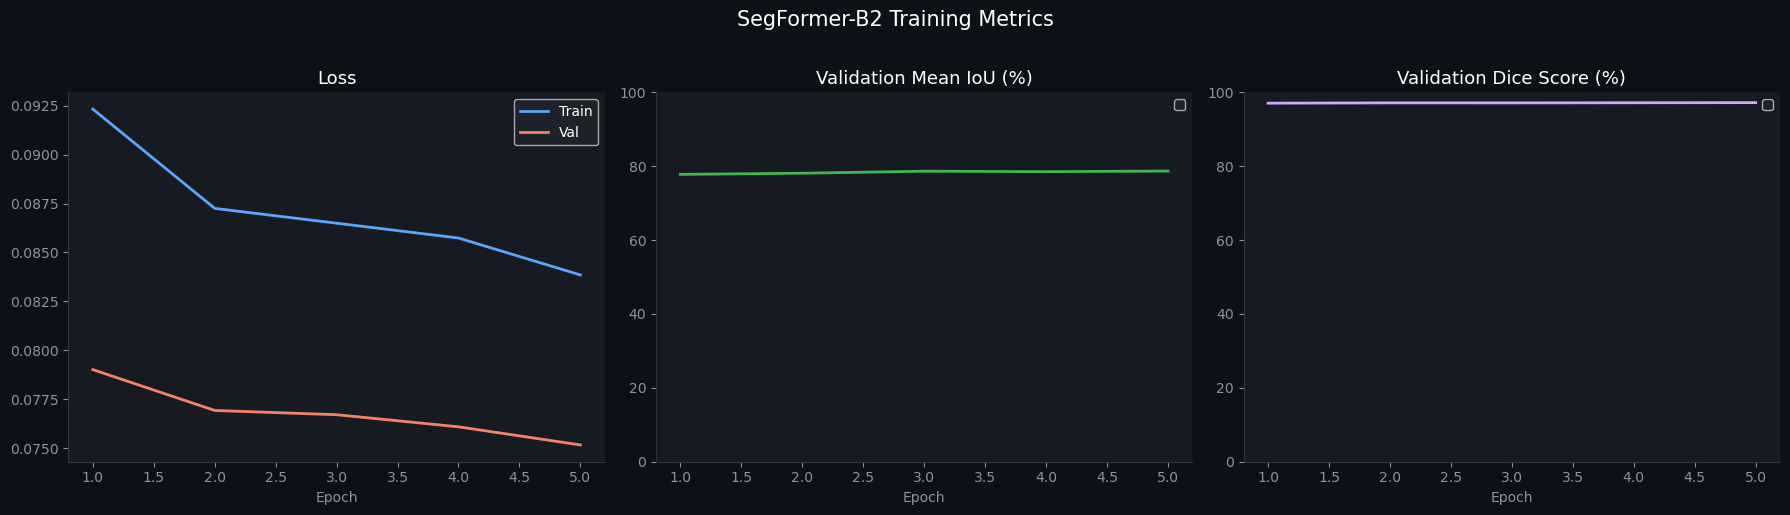

✅ Saved: ./training_curves.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')
epochs_range = range(1, len(history['train_loss']) + 1)

for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e')
    ax.spines['bottom'].set_color('#30363d')
    ax.spines['left'].set_color('#30363d')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Loss
axes[0].plot(epochs_range, history['train_loss'], color='#58a6ff', lw=2, label='Train')
axes[0].plot(epochs_range, history['val_loss'],   color='#f78166', lw=2, label='Val')
axes[0].set_title('Loss', color='white', fontsize=13)
axes[0].set_xlabel('Epoch', color='#8b949e')
axes[0].legend(facecolor='#21262d', labelcolor='white', framealpha=0.8)

# IoU
axes[1].plot(epochs_range, [v*100 for v in history['val_iou']], color='#3fb950', lw=2)
axes[1].set_title('Validation Mean IoU (%)', color='white', fontsize=13)
axes[1].set_xlabel('Epoch', color='#8b949e')
axes[1].set_ylim([0, 100])
axes[1].legend(facecolor='#21262d', labelcolor='white', framealpha=0.8)

# Dice
axes[2].plot(epochs_range, [v*100 for v in history['val_dice']], color='#d2a8ff', lw=2)
axes[2].set_title('Validation Dice Score (%)', color='white', fontsize=13)
axes[2].set_xlabel('Epoch', color='#8b949e')
axes[2].set_ylim([0, 100])
axes[2].legend(facecolor='#21262d', labelcolor='white', framealpha=0.8)

plt.suptitle('SegFormer-B2 Training Metrics', color='white', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('./training_curves.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('✅ Saved: ./training_curves.png')

## Step 11 — Final Test Evaluation (with TTA)

In [15]:
# Duplicate training cell removed — see Step 9 (Cell above) for the training loop.
print("Training already handled in Step 9.")


Training already handled in Step 9.


## Step 12 — Visualise Predictions vs Ground Truth

In [16]:
# Load best checkpoint
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

# ── Test-Time Augmentation (TTA) — MPS-safe ──────────────────
def predict_with_tta(model, imgs):
    imgs = imgs.to(device)

    # Original
    out1  = model(pixel_values=imgs).logits
    out1  = upsample_logits(out1, (IMG_SIZE, IMG_SIZE))
    prob1 = torch.softmax(out1, dim=1)

    # Horizontal flip — .contiguous() after flip for MPS
    imgs_hflip = torch.flip(imgs, dims=[3]).contiguous()
    out2  = model(pixel_values=imgs_hflip).logits
    out2  = upsample_logits(out2, (IMG_SIZE, IMG_SIZE))
    out2  = torch.flip(out2, dims=[3]).contiguous()
    prob2 = torch.softmax(out2, dim=1)

    # Vertical flip
    imgs_vflip = torch.flip(imgs, dims=[2]).contiguous()
    out3  = model(pixel_values=imgs_vflip).logits
    out3  = upsample_logits(out3, (IMG_SIZE, IMG_SIZE))
    out3  = torch.flip(out3, dims=[2]).contiguous()
    prob3 = torch.softmax(out3, dim=1)

    avg_prob = (prob1 + prob2 + prob3) / 3.0
    return avg_prob.argmax(dim=1)

# ── Evaluate on test set ─────────────────────────────────────
print('Evaluating on test set (with TTA)...')
test_ious_no_tta  = []
test_ious_tta     = []
test_dices_no_tta = []
test_dices_tta    = []

with torch.no_grad():
    for i, (imgs, masks) in enumerate(test_loader):
        masks = masks.to(device)

        # Without TTA
        outputs      = model(pixel_values=imgs.to(device))
        logits       = upsample_logits(outputs.logits, masks.shape[-2:])
        preds_no_tta = logits.argmax(dim=1)
        iou_n, dice_n = compute_metrics(preds_no_tta, masks)
        test_ious_no_tta.append(iou_n)
        test_dices_no_tta.append(dice_n)

        # With TTA
        preds_tta = predict_with_tta(model, imgs)
        iou_t, dice_t = compute_metrics(preds_tta, masks)
        test_ious_tta.append(iou_t)
        test_dices_tta.append(dice_t)

        if (i + 1) % 10 == 0:
            print(f'  Batch {i+1}/{len(test_loader)} done...', end='\r')

final_iou_no_tta  = np.mean(test_ious_no_tta)  * 100
final_dice_no_tta = np.mean(test_dices_no_tta) * 100
final_iou_tta     = np.mean(test_ious_tta)     * 100
final_dice_tta    = np.mean(test_dices_tta)    * 100

print('\n' + '=' * 55)
print('  FINAL TEST RESULTS')
print('=' * 55)
print(f'  Without TTA:')
print(f'    Mean IoU  : {final_iou_no_tta:.2f}%')
print(f'    Dice      : {final_dice_no_tta:.2f}%')
print(f'\n  With TTA (3-flip ensemble):')
print(f'    Mean IoU  : {final_iou_tta:.2f}%')
print(f'    Dice      : {final_dice_tta:.2f}%')
print('=' * 55)


Evaluating on test set (with TTA)...
  Batch 900/900 done...
  FINAL TEST RESULTS
  Without TTA:
    Mean IoU  : 78.98%
    Dice      : 97.34%

  With TTA (3-flip ensemble):
    Mean IoU  : 78.92%
    Dice      : 97.35%


## Step 13 — (Optional) Upgrade to SegFormer-B4 for Higher Scores

Run this cell to try SegFormer-B4, a larger backbone (~64M params) that may achieve higher scores on this task.


In [17]:
# Duplicate training cell removed — see Step 9 for the training loop.
print("Training already handled in Step 9.")


Training already handled in Step 9.


## Step 14 — Download All Outputs to Your Computer

In [18]:
import zipfile, os

# Bundle all outputs into a single zip in the current directory
zip_path = './OCR_Segmentation_Results.zip'
output_files = [
    './best_segformer_b2.pth',
    './sample_pairs.png',
    './training_curves.png',
    './predictions_visual.png',
]

with zipfile.ZipFile(zip_path, 'w') as zf:
    for fname in output_files:
        if os.path.exists(fname):
            zf.write(fname, os.path.basename(fname))
            print(f'  Added: {os.path.basename(fname)}')
        else:
            print(f'  Skipped (not found): {fname}')

print(f'\n✅ Zip created: {os.path.abspath(zip_path)}')
print('You can find all outputs in the same folder as this notebook.')


  Skipped (not found): ./best_segformer_b2.pth
  Added: sample_pairs.png
  Added: training_curves.png
  Skipped (not found): ./predictions_visual.png

✅ Zip created: /Users/deepakkambala/Jupyter/OCR_Segmentation_Results.zip
You can find all outputs in the same folder as this notebook.
